Connecting with Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing required libraries

In [ ]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os, time
import pandas as pd

# Deep Learning imports
import tensorflow as tf
from tensorflow import keras

# To plot nice figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
mpl.rc('figure', dpi=100)
import seaborn as sns;

---
---
# Load, inspect and prepare the data

## Data loading


In [ ]:
# Load training sets
import numpy as np
train_ai = np.load('/content/drive/My Drive/data/train_ai.npy')
train_human = np.load('/content/drive/My Drive/data/train_human.npy')

# Load validation set
valid_set = pd.read_json("/content/drive/My Drive/data/validation.jsonl", lines=True)
# Load test set
test_set = pd.read_json('/content/drive/My Drive/data/test_features.jsonl', lines=True)

In [ ]:
# Combine the training sets of humman-written and Ai-generated text samples

X_train = np.concatenate([train_ai, train_human], axis=0)
y_train = np.concatenate([np.ones(train_ai.shape[0]), np.zeros(train_human.shape[0])])
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train, random_state=42)

X_train.shape, y_train.shape

((16322, 100, 768), (16322,))

In [ ]:
# Check the dataset shapes
print("AGT training set shape:", train_ai.shape)
print("HWT training set shape:", train_human.shape)
print("Validation set", valid_set.shape)
print("Test data set", test_set.shape)


AGT training set shape: (8161, 100, 768)
HWT training set shape: (8161, 100, 768)
Validation set (20, 3)
Test data set (180, 2)


In [ ]:
# Display the first samples of human-written and Ai-generated text samples
print(f"-----The first human-written text sample in the training set-----\n {train_human[0]}")
print("\n")
print(f"-----The first AI-Generated text sample in the training set------\n {train_ai[0]}")

-----The first human-written text sample in the training set-----
 [[-0.28357378 -0.07436191 -0.1486315  ...  0.03567392 -0.01210558
  -0.04643903]
 [-0.30341238 -0.0314039  -0.17742279 ...  0.01925613  0.01672407
  -0.04707547]
 [-0.24501228  0.0186932  -0.00043371 ...  0.05649162  0.02669747
   0.05548369]
 ...
 [-0.         -0.         -0.         ... -0.          0.
  -0.        ]
 [-0.         -0.         -0.         ... -0.          0.
  -0.        ]
 [-0.         -0.         -0.         ... -0.          0.
  -0.        ]]


-----The first AI-Generated text sample in the training set------
 [[-0.40066403  0.21204428  0.16675226 ...  0.01592983  0.27658018
   0.327394  ]
 [-0.42732263  0.05664812  0.08518381 ... -0.05453362  0.22192582
   0.25310516]
 [-0.37602055  0.15580429  0.17277488 ... -0.02350055  0.24987884
   0.32764766]
 ...
 [-0.          0.          0.         ... -0.          0.
   0.        ]
 [-0.          0.          0.         ... -0.          0.
   0.        ]
 [

In [ ]:
# Display the first few samples of the validation set
valid_set.head()

,id,features,label
0,0,"[[[-0.24490666389465302, 0.07313243299722601, ...",0
1,1,"[[[-0.49410030245780906, 0.126586645841598, 0....",0
2,2,"[[[-0.256337642669677, -0.042896009981632004, ...",0
3,3,"[[[-0.47554060816764804, 0.167076677083969, 0....",1
4,4,"[[[-0.42083767056465105, 0.23019495606422402, ...",1


In [ ]:
# Display the first few samples of the test set
test_set.head()

,id,features
0,15,"[[[-0.22664156556129403, -0.044935300946235004..."
1,16,"[[[-0.42181262373924205, 0.21923619508743203, ..."
2,17,"[[[-0.224436491727828, -0.07920632511377301, -..."
3,18,"[[[-0.27979409694671603, 0.12262184917926701, ..."
4,19,"[[[-0.24358090758323603, 0.034845128655433, 0...."


## Data visualisation

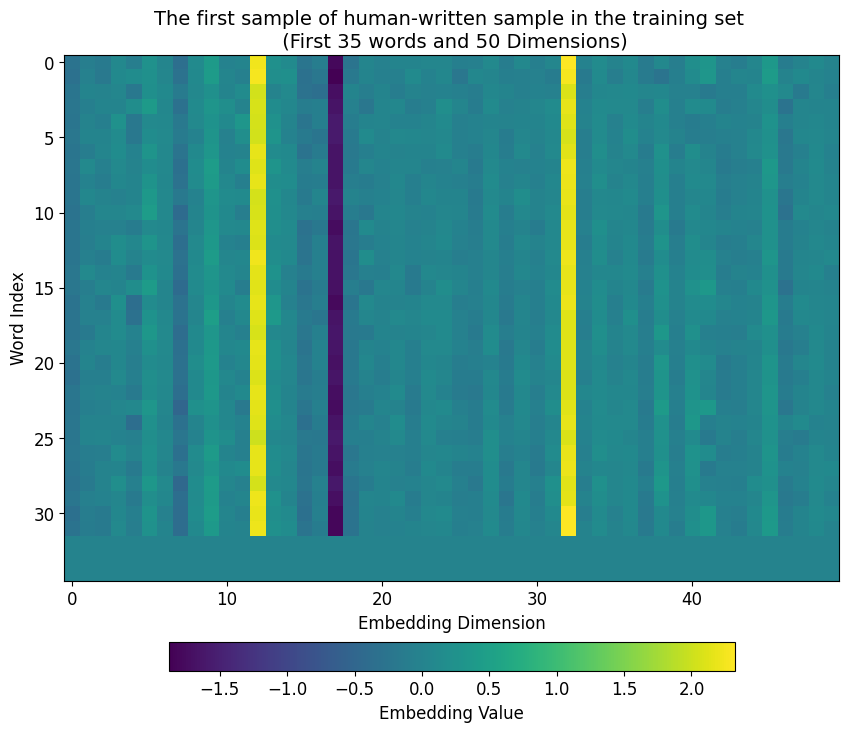

In [ ]:
# Heatmap of the first sample of human-written sample in the training set
plt.figure(figsize=(10,8))
im = plt.imshow(train_human[0][:35, :50], cmap='viridis', aspect='auto')

plt.title(f'The first sample of human-written sample in the training set \n (First 35 words and 50 Dimensions)', fontsize=14)
plt.xlabel('Embedding Dimension', fontsize=12)
plt.ylabel('Word Index', fontsize=12)

cbar = plt.colorbar(im, orientation='horizontal', fraction=0.046, pad=0.1)
cbar.set_label('Embedding Value', fontsize=12)

plt.show()


The above heatmap shows the embedding values of the first 35 words across 50 dimensions of the human written training sample. The variation in colour reflects how word tokens are represented in high dimensional space, though no clear pattern is visually distinguishable

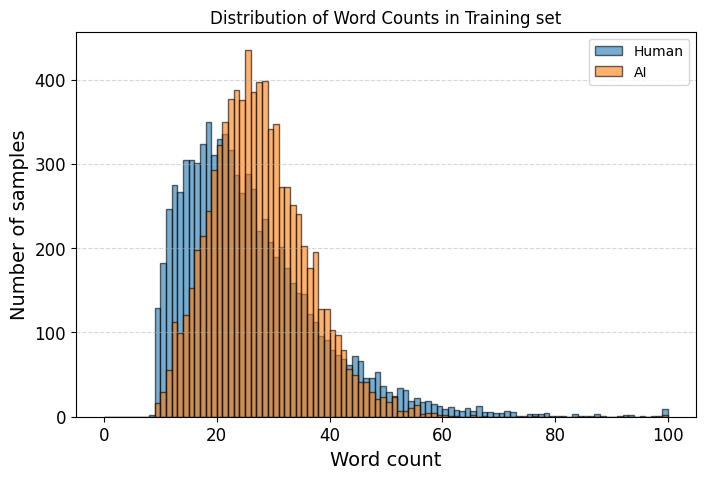

In [ ]:
# Create histograms of distribution of the two type in the training set
word_counts_train_human = np.count_nonzero( np.any(train_human != 0, axis=2), axis=1)
word_counts_train_ai = np.count_nonzero( np.any(train_ai != 0, axis=2), axis=1)

plt.figure(figsize=(8,5))
plt.hist(word_counts_train_human, bins=range(0,101), alpha=0.6, label='Human', edgecolor='black')
plt.hist(word_counts_train_ai, bins=range(0,101), alpha=0.6, label='AI', edgecolor='black')
plt.title("Distribution of Word Counts in Training set")
plt.xlabel("Word count")
plt.ylabel("Number of samples")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


The above figure shows the distribution of word counts in the training set for human-written and AI-generated sentences. The figure suggests that AI generated texts contains more words on average while human-written text are shorter and more varied on length

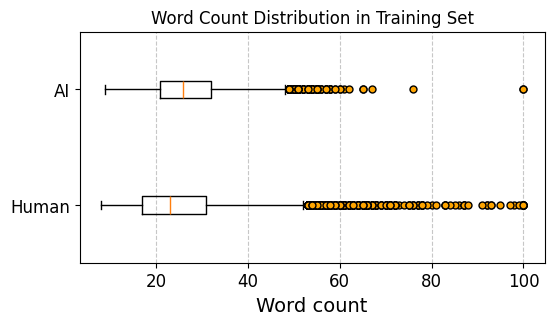

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.boxplot([word_counts_train_human, word_counts_train_ai],
            tick_labels=['Human', 'AI'],
            vert=False,
            flierprops=dict(markerfacecolor='orange', marker='o', markersize=5, linestyle='none'))
plt.title("Word Count Distribution in Training Set")
plt.xlabel("Word count")       # horizontal axis is now the word count
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


The box plot illustrates that AI-generated texts have slightly higher median word count and is more consistent on length. However, human generated text significantly vary in length and have much larger number of outliers representing longer sentences

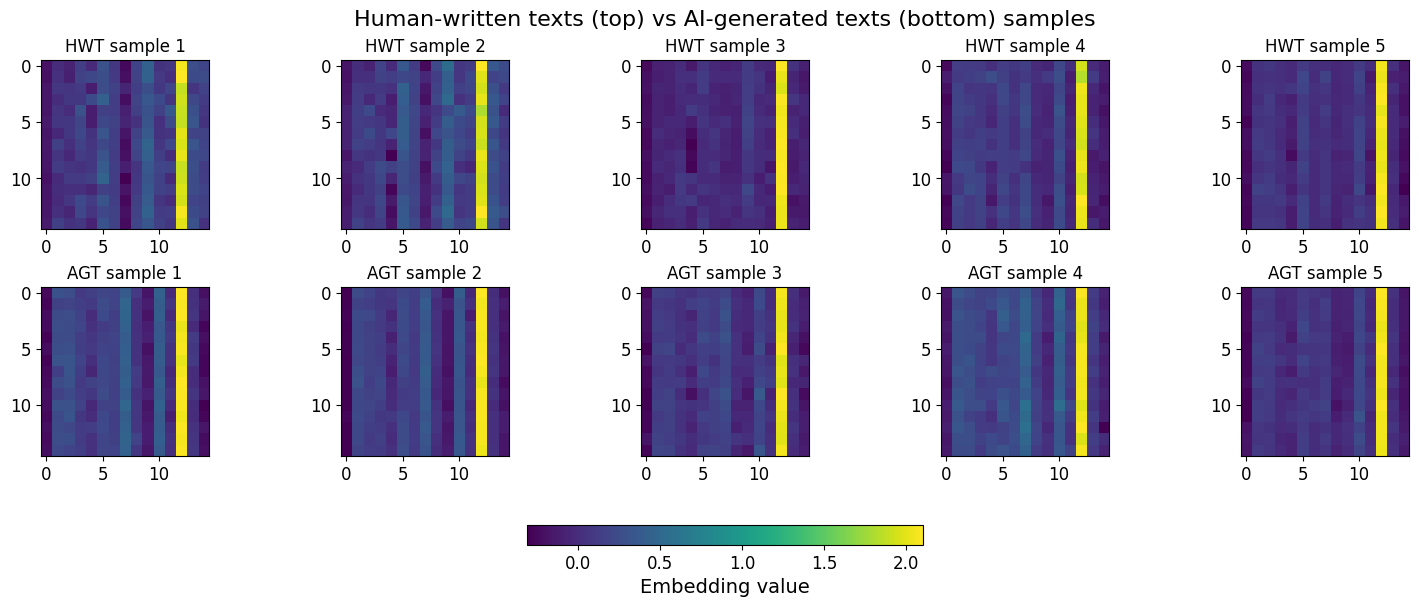

In [ ]:
# Ceate heatmaps of 5 human-written texts and 5 Ai-generated texts samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6),constrained_layout = True)
fig.suptitle("Human-written texts (top) vs AI-generated texts (bottom) samples", fontsize=16)

for col in range(5):
    # Add plots for human-written texts in the first rows
    heatmap_human = train_human[col][:15, :15]
    im = axes[0, col].imshow(heatmap_human, cmap='viridis')
    axes[0, col].set_title(f"HWT sample {col+1}")


    # Add plots for AI-generated texts in the first rows
    heatmap_ai = train_ai[col][:15, :15]
    axes[1, col].imshow(heatmap_ai, cmap='viridis')
    axes[1, col].set_title(f"AGT sample {col+1}")

cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('Embedding value')

plt.show()


The above heatmap compares the word embedding values for five samples of human written text and AI generated text. The top row represents human written text while lower rows are AI generated text. It suggests that there is no obvious or consistent patterns that distinguishes the human text from AI text, indicating very thin layer of differences between them

Performing EDA with PCA
Shape of averaged sample features for PCA: (5000, 768)


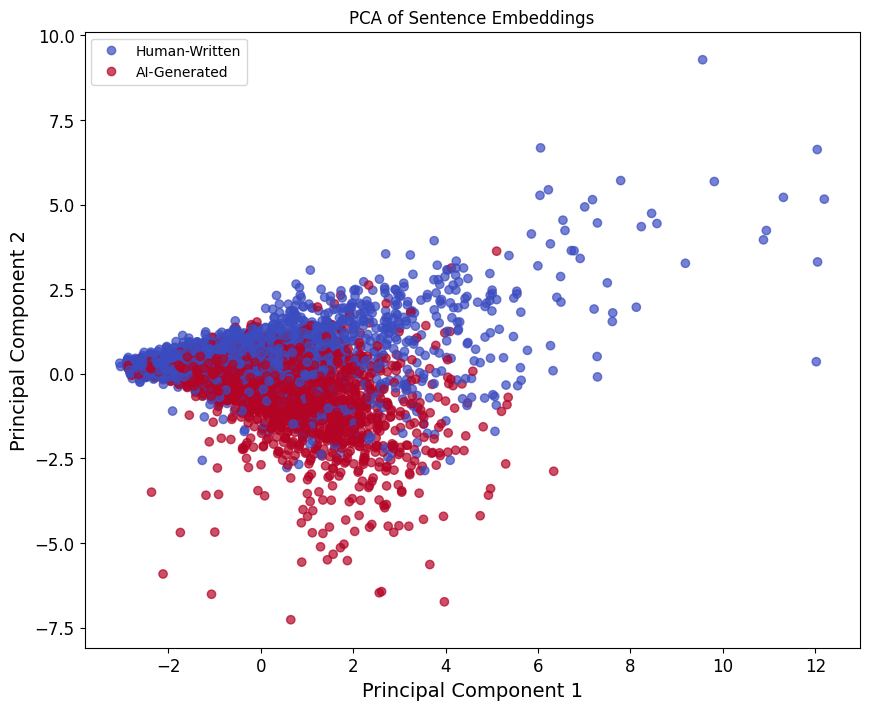

In [ ]:
# Perform EDA with PCA
from sklearn.decomposition import PCA

print("Performing EDA with PCA")

# Take a subset for faster plotting
sample_size = 5000
X_sample = X_train[:sample_size]
y_sample = y_train[:sample_size]

# Average across the time dimension (100 tokens)
X_sample_avg = np.mean(X_sample, axis=1)
print(f"Shape of averaged sample features for PCA: {X_sample_avg.shape}")

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample_avg)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap='coolwarm', alpha=0.7)
plt.title('PCA of Sentence Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['Human-Written', 'AI-Generated'])
plt.show()

The above figure visualizes the differences between human-written (blue) and AI-generated (red) sentence embeddings using PCA, revealing a noticeable separation between the two type of texts.

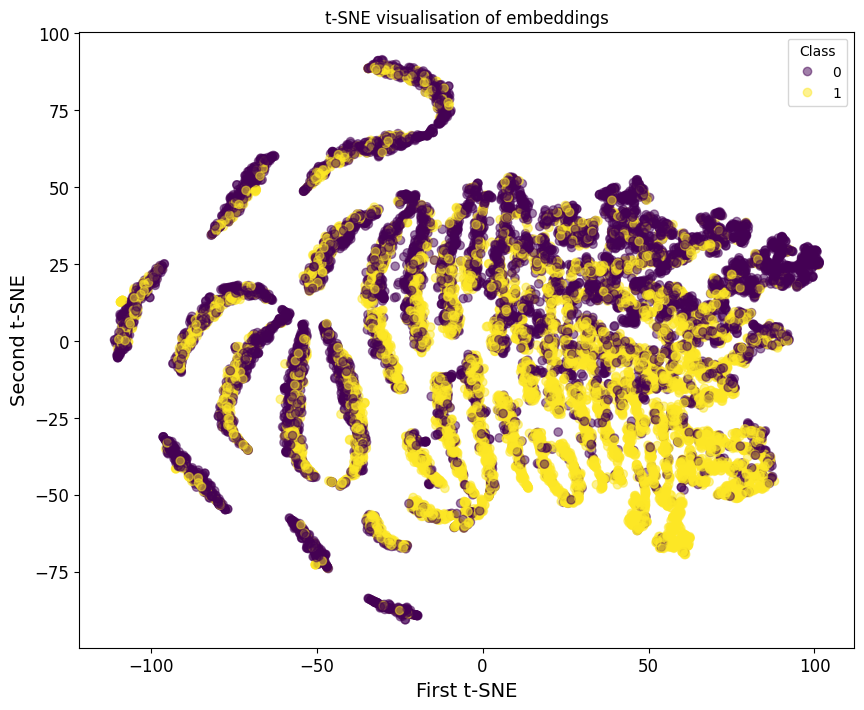

In [ ]:
# Produce T-SNE visualisation
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
X_pooled = X_train.mean(axis=1)

tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(X_pooled)

plt.figure(figsize=(10,8))
scatter = plt.scatter(reduced[:,0], reduced[:,1], c=y_train, cmap='viridis', alpha=0.5)
plt.legend(*scatter.legend_elements(), title="Class")
plt.title("t-SNE visualisation of embeddings")
plt.xlabel('First t-SNE')
plt.ylabel('Second t-SNE')
plt.show()


The t-SNE visualization indicates that the data embeddings form distinct clusters, suggesting underlying structural similarities. However, among these clusters, some clusters are so inter-related with each other, it is very hard to separate based on features captured by the embeddings.

## Data preparation

### Prepare the validation set

In [ ]:
# Extract each sentence in the paragraphs of the validation set into individual samples
valid_set_expanded = valid_set.explode(["features"], ignore_index=True)
valid_set_expanded.head()

,id,features,label
0,0,"[[-0.24490666389465302, 0.07313243299722601, 0...",0
1,0,"[[-0.19175654649734403, -0.023217573761940002,...",0
2,0,"[[-0.20219510793685902, 0.043169509619474, 0.0...",0
3,0,"[[-0.35767996311187705, 0.20171597599983201, 0...",0
4,1,"[[-0.49410030245780906, 0.126586645841598, 0.0...",0


In [ ]:
# Store each sentence samples in X_valid and their labels in y_valid
X_valid = valid_set_expanded["features"]
X_valid = np.stack(X_valid.tolist())
y_valid = valid_set_expanded['label']
X_valid.shape, y_valid.shape

((220, 100, 768), (220,))

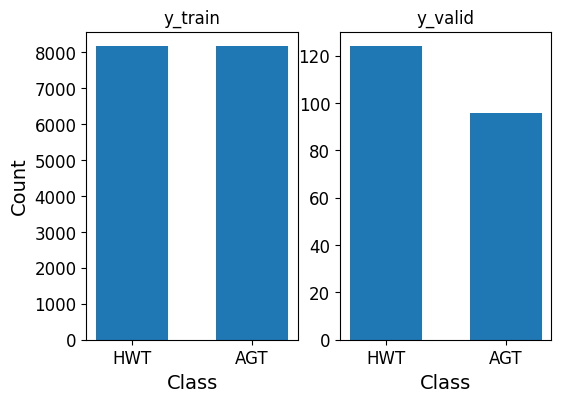

In [ ]:
# Have look at the distribution of the labels in the training and validation sets
fig, sub = plt.subplots(1, 2, figsize = (6,4))

sub[0].hist(y_train, bins=[-0.5, 0.5, 1.5], rwidth=0.6)
sub[0].set_ylabel('Count')
sub[0].set_xlabel('Class')
sub[0].set_title('y_train')
sub[0].set_xticks([0,1])
sub[0].set_xticklabels(['HWT', 'AGT'])
sub[1].hist(y_valid, bins=[-0.5, 0.5, 1.5], rwidth=0.6)
sub[1].set_xlabel('Class')
sub[1].set_title('y_valid')
sub[1].set_xticks([0,1])
sub[1].set_xticklabels(['HWT', 'AGT'])
plt.show()

### Prepare the test set

In [ ]:
# Extract each sentence in the paragraphs of the test set into individual samples
test_set_expanded = test_set.explode(["features"], ignore_index=True)
X_test = test_set_expanded["features"]
X_test = np.stack(X_test.tolist())
X_test.shape

(1686, 100, 768)

---
---
# Modelling


## Define helper functions

In [ ]:
# Build a CNN

def model_cnn_factory(hiddensizes, actfn, optimizer, learningrate):
    model = keras.models.Sequential()
    model.add(keras.layers.Conv1D(filters=hiddensizes[0], kernel_size=3, strides=1, activation=actfn, padding="same"))
    model.add(keras.layers.MaxPooling1D(pool_size=2))
    model.add(keras.layers.Dropout(0.2))
    for n in hiddensizes[1:-1]:
        model.add(keras.layers.Conv1D(filters=n, kernel_size=3, strides=1, padding="same", activation=actfn))
        model.add(keras.layers.MaxPooling1D(pool_size=2))
        model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Conv1D(filters=hiddensizes[-1], kernel_size=3, strides=1, padding="same", activation=actfn))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dropout(0.3))
    model.add(keras.layers.Dense(1, activation = "sigmoid"))
    model.build(input_shape=(None, 100, 768))
    model.compile(loss="binary_crossentropy", optimizer=optimizer(learning_rate=learningrate), metrics=["accuracy"])
    return model

In [ ]:
# Early stopping callback
early_stopping_cb = keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                                  patience=5,
                                                  restore_best_weights=True)

In [ ]:
def do_all(hiddensizes, actfn, optimizer, learningrate, X_train, y_train, X_val, y_val, n_epochs, batch_size, further_callbacks=[]):
    if further_callbacks != []:
        callbacks = further_callbacks
    else:
        callbacks = [early_stopping_cb]
    model = model_cnn_factory(hiddensizes, actfn, optimizer, learningrate)
    history = model.fit(X_train, y_train, epochs=n_epochs,batch_size= batch_size, callbacks = [early_stopping_cb] + further_callbacks,
                        validation_data=(X_val, y_val),verbose=1)
    max_val_acc = np.max(history.history['val_accuracy'])
    return (max_val_acc, history, model)

In [ ]:
# Plot the results (shifting validation curves appropriately)
def plot_history(history):
    plt.figure(figsize=(8,3))
    n = len(history.history['accuracy'])
    plt.plot(np.arange(0,n),history.history['accuracy'], color='orange',marker=".")
    plt.plot(np.arange(0,n),history.history['loss'],'b',marker=".")
    plt.plot(np.arange(0,n)+0.5,history.history['val_accuracy'],'r',marker=".")  # offset both validation curves
    plt.plot(np.arange(0,n)+0.5,history.history['val_loss'],'g',marker=".")
    plt.legend(['Train Acc','Train Loss','Val Acc','Val Loss'])
    plt.grid(True)
    plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
    plt.show()

## Define modelling parameters

In [ ]:
hiddensizes = [128, 256, 128]
actfn = "relu"
optimizer = keras.optimizers.Adam
learningrate = 0.0001
batch_size = 128
n_epochs = 30

## Build a Convolutional Neural Network

In [ ]:
max_val_acc, history, model = do_all(hiddensizes, actfn, optimizer, learningrate, X_train, y_train, X_valid, y_valid, n_epochs, batch_size)

Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.7004 - loss: 0.5702 - val_accuracy: 0.6136 - val_loss: 0.7156
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8215 - loss: 0.4046 - val_accuracy: 0.6909 - val_loss: 0.7192
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8632 - loss: 0.3179 - val_accuracy: 0.7364 - val_loss: 0.6906
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8739 - loss: 0.2925 - val_accuracy: 0.7045 - val_loss: 0.7116
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8839 - loss: 0.2749 - val_accuracy: 0.7000 - val_loss: 0.8081
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8912 - loss: 0.2605 - val_accuracy: 0.7091 - val_loss: 0.7856
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8908 - loss: 0.2616 - val_accuracy: 0.7091 - val_loss: 0.7201
Epoch 8/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8947 - loss: 0.2553 - val_acc

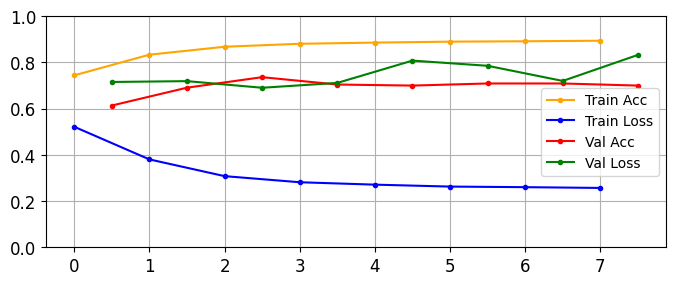

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 128)       │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 25, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         3,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,485,701 (5.67 MB)

 Trainable params: 495,233 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 990,468 (3.78 MB)

In [ ]:
# Inspect the training process
plot_history(history)
model.summary()

## Prediction on Test Set

In [ ]:
test_preds = model.predict(X_test).flatten()

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [ ]:
test_preds
test_pred_df = pd.DataFrame({'id': test_set_expanded['id'].values, 'label': test_preds.tolist()})
test_pred_df


,id,label
0,15,0.105438
1,15,0.013254
2,15,0.053633
3,15,0.074081
4,15,0.547357
...,...,...
1681,199,0.701801
1682,199,0.290447
1683,199,0.922825
1684,199,0.973704


In [ ]:
test_pred_df = test_pred_df.groupby('id')['label'].mean().reset_index()
test_pred_df.head(20)

,id,label
0,15,0.258598
1,16,0.261852
2,17,0.239115
3,18,0.471752
4,19,0.435524
5,21,0.246784
6,24,0.238830
7,25,0.555469
8,27,0.282209
9,29,0.589297


In [ ]:
# Save the prediction file and the model
test_pred_df.to_csv("Mon_PM_Group_1.csv", index=False)
model.save("Mon_PM_Group_1.keras")


# Load the final model and predict on the test set

In [ ]:
from tensorflow.keras.models import load_model
model1 = load_model("Mon_PM_Group_1.keras")

In [ ]:
test_preds1 = model1.predict(X_test).flatten()

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [ ]:
test_pred_df1 = pd.DataFrame({'id': test_set_expanded['id'].values, 'label': test_preds1.tolist()})
test_pred_df1 = test_pred_df1.groupby('id')['label'].mean().reset_index()
test_pred_df1.head(20)

,id,label
0,15,0.258598
1,16,0.261852
2,17,0.239115
3,18,0.471752
4,19,0.435524
5,21,0.246784
6,24,0.238830
7,25,0.555469
8,27,0.282209
9,29,0.589297
